In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [15]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, unroll_time, get_targets_and_masks

In [3]:
from functools import partial

In [4]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [11]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [12]:
config['axis']

2

In [13]:
config['batch_size']

1000

In [8]:
agent = SA(config, 42)

xs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = xs.shape

In [14]:
n

467

In [26]:
tgts, hw, mask = get_targets_and_masks(xs, ts, cs, landmark=True)

In [28]:
hw[2]

Array([[1., 1., 1., 0., 0.],
       [1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

In [51]:
n_folds

5

In [32]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)
seqs = xs

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
    )

In [50]:
%%time

sizes = 20 * jnp.arange(1, 11)

res2_is = np.zeros((n_folds, len(sizes)))
res2_lm = np.zeros((n_folds, len(sizes)))
res2_td = np.zeros((n_folds, len(sizes)))

res3_is = np.zeros((n_folds, len(sizes)))
res3_lm = np.zeros((n_folds, len(sizes)))
res3_td = np.zeros((n_folds, len(sizes)))

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v) = get_fold(fold)
    tgt_t_is, ms_t_is, _ = get_targets_and_masks(seqs_t, ts_t, cs_t, landmark=False)
    tgt_t_lm, ms_t_lm, _ = get_targets_and_masks(seqs_t, ts_t, cs_t, landmark=True)
    tgt_v_is, ms_v_is, _ = get_targets_and_masks(seqs_v, ts_v, cs_v, landmark=False)
    
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seqs_t
        train_gen.ts = ts_t
        train_gen.cs = cs_t
        train_gen.mask = ms_t_is
        train_gen.y = tgt_t_is

        print('fold', fold, 'len train ', train_gen.X.shape)
    
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs_v)
        surv_, ts_, cs_, ms_ = unroll_time(surv, ts_v, cs_v, ms_v_is, model.horizon)
        res2_is[fold, i] = model.integrated_brier_score(surv_, ts_, cs_, ms_)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs_v.reshape(-1, seqs_v.shape[-1])
        scores = score(beta, seqs_v[:,0])
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)

        ms_is_ = jnp.copy(ms_)
        
        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seqs_t
        train_gen.ts = ts_t
        train_gen.cs = cs_t
        train_gen.mask = ms_t_lm
        train_gen.y = tgt_t_lm
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs_v)
        surv_, ts_, cs_, ms_ = unroll_time(surv, ts_v, cs_v, ms_v_is, model.horizon)
        res2_lm[fold, i] = model.integrated_brier_score(surv_, ts_, cs_, ms_is_)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs_v.reshape(-1, seqs_v.shape[-1])
        scores = score(beta, seqs_v[:,0])
        res3_lm[fold, i] = concordance_index(scores, ts_v, cs_v)
        
    print()

.fold 0 len train  (374, 5, 5)
.fold 0 len train  (374, 5, 5)
.fold 0 len train  (374, 5, 5)
.fold 0 len train  (374, 5, 5)
.

KeyboardInterrupt: 

Text(0.5, 0, 'Test size proportion')

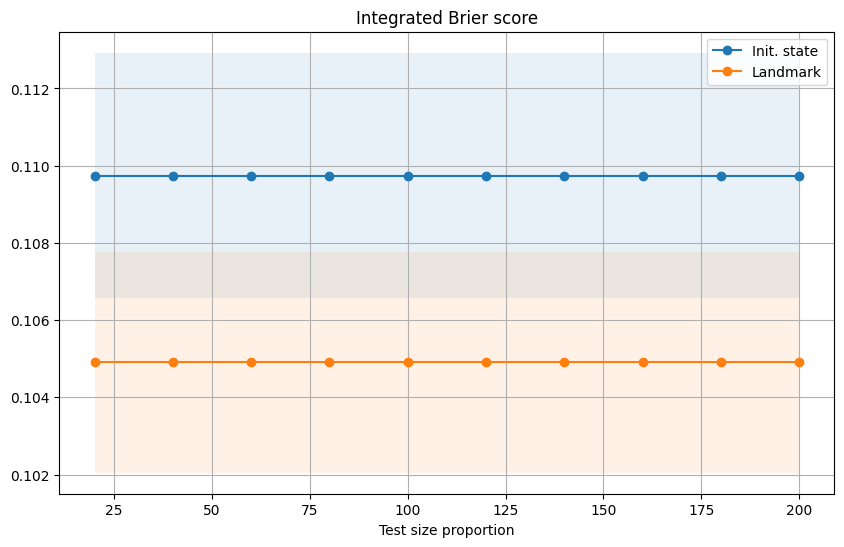

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Number of patients')

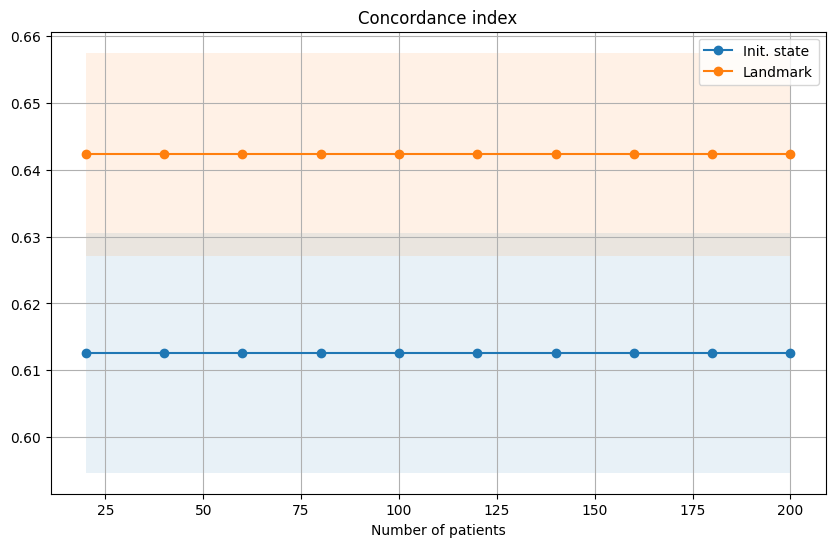

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [38]:
res3_is

array([[0.63321947, 0.63321947, 0.63321947, 0.63321947, 0.63321947,
        0.63321947, 0.63321947, 0.63321947, 0.63321947, 0.63321947],
       [0.59685864, 0.59685864, 0.59685864, 0.59685864, 0.59685864,
        0.59685864, 0.59685864, 0.59685864, 0.59685864, 0.59685864],
       [0.68072552, 0.68072552, 0.68072552, 0.68072552, 0.68072552,
        0.68072552, 0.68072552, 0.68072552, 0.68072552, 0.68072552],
       [0.58176101, 0.58176101, 0.58176101, 0.58176101, 0.58176101,
        0.58176101, 0.58176101, 0.58176101, 0.58176101, 0.58176101],
       [0.57043175, 0.57043175, 0.57043175, 0.57043175, 0.57043175,
        0.57043175, 0.57043175, 0.57043175, 0.57043175, 0.57043175]])

In [47]:
(seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v) = get_fold(4)

In [48]:
seqs_t.shape

(373, 5, 5)